# Open Notebook & Additional Resources

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/hands-on-multimodal-AI/blob/main/hands-on/HANDS_ON_session_05_Multimodal_RAG_Pipeline.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://www.oreilly.com/library/view/transformers-the-definitive/9781098167004/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="Transformers: The Definitive Guide"/>
</a>




<font color="red" size="10">
<b>HANDS-ON TIME: 15 mins</b>
</font>

# Simplified Multimodal Extraction + Q&A (PDF + Receipt)

This notebook is intentionally minimal and focuses on one concrete task:

**Extract structured data from tables in a PDF and ask questions about its content.**

We use only two sources:
- Qwen3 technical report PDF: `https://arxiv.org/pdf/2505.09388.pdf`
- Receipt image (SROIE fixture): `https://huggingface.co/datasets/hf-internal-testing/fixtures_ocr/resolve/main/SROIE-receipt.jpeg`

And only two models:
- OCR: `lightonai/LightOnOCR-2-1B`
- Structured extraction + Q&A: `Qwen/Qwen3-VL-2B-Instruct`

No Docling, embedding, vector DB, or reranker in this simplified version.






## Setup

In [1]:
%%capture
%pip install -q "transformers>=5.0.0" pymupdf pillow matplotlib requests qwen-vl-utils

## Imports + Configuration

In [2]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import fitz
import requests
import torch
from PIL import Image
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

PDF_SOURCE = {
    "name": "arxiv_qwen3",
    "url": "https://arxiv.org/pdf/2505.09388.pdf",
    "desc": "Technical report with dense tables and benchmarks (Qwen3)",
}

RECEIPT_URL = "https://huggingface.co/datasets/hf-internal-testing/fixtures_ocr/resolve/main/SROIE-receipt.jpeg"

WORKDIR = Path("scratch/simplified_multimodal")
WORKDIR.mkdir(parents=True, exist_ok=True)

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")


Using device: cuda


In [3]:
def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        print(f"Using cached file: {output_path}")
        return output_path

    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with output_path.open("wb") as f:
        for chunk in r.iter_content(1024 * 1024):
            if chunk:
                f.write(chunk)

    print(f"Downloaded: {output_path}")
    return output_path


def render_pdf_page(pdf_path: Path, page_index: int, max_dim: int = 1400) -> Image.Image:
    doc = fitz.open(pdf_path)
    page = doc[page_index]
    pix = page.get_pixmap(alpha=False)
    doc.close()

    image = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
    w, h = image.size
    scale = min(1.0, max_dim / max(w, h))
    if scale < 1.0:
        image = image.resize((int(w * scale), int(h * scale)))
    return image

Downloaded: scratch/simplified_multimodal/arxiv_qwen3.pdf
Downloaded: scratch/simplified_multimodal/sroie_receipt.jpeg


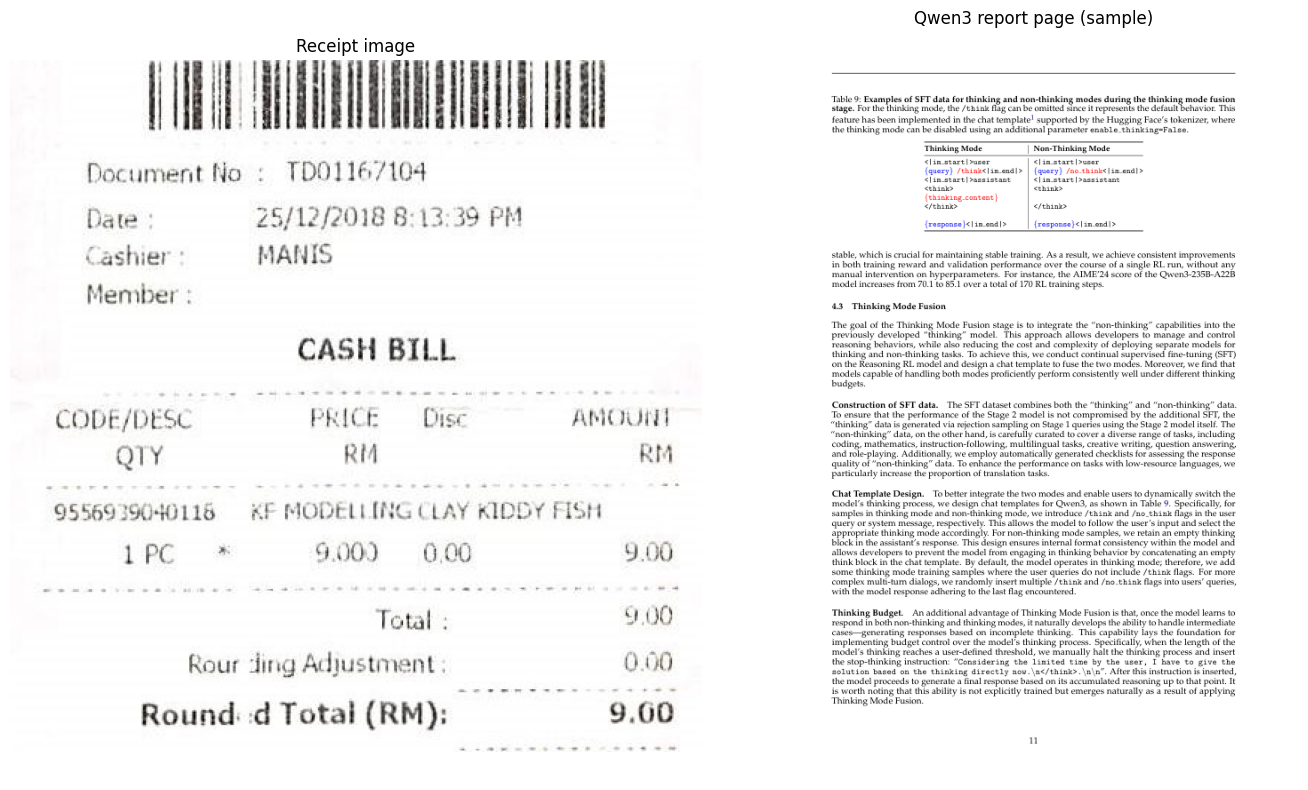

In [4]:

pdf_path = download_file(PDF_SOURCE["url"], WORKDIR / "arxiv_qwen3.pdf")
receipt_path = download_file(RECEIPT_URL, WORKDIR / "sroie_receipt.jpeg")

receipt_image = Image.open(receipt_path).convert("RGB")
pdf_page_for_extraction = render_pdf_page(pdf_path, page_index=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(receipt_image)
axes[0].set_title("Receipt image")
axes[0].axis("off")
axes[1].imshow(pdf_page_for_extraction)
axes[1].set_title("Qwen3 report page (sample)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## OCR Model (LightOnOCR-2-1B)

Load the OCR model once, then reuse it for:
- extracting raw text from the receipt image
- extracting raw text from a selected PDF page image

In [5]:
from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor

ocr_dtype = torch.float32 if device == "mps" else torch.bfloat16
OCR_MODEL_ID = "lightonai/LightOnOCR-2-1B"

ocr_model = LightOnOcrForConditionalGeneration.from_pretrained(
    OCR_MODEL_ID,
    torch_dtype=ocr_dtype,
).to(device)
ocr_processor = LightOnOcrProcessor.from_pretrained(OCR_MODEL_ID)


@torch.inference_mode()
def run_lighton_ocr(images: list[Image.Image], max_new_tokens: int = 2048) -> list[str]:
    # Process images one-by-one for robustness. Some model/processor versions
    # collapse batched chat inputs into a single sample.
    outputs: list[str] = []
    for img in images:
        conversation = [{"role": "user", "content": [{"type": "image", "image": img}]}]
        inputs = ocr_processor.apply_chat_template(
            conversation,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        inputs = {
            k: v.to(device=device, dtype=ocr_dtype) if v.is_floating_point() else v.to(device)
            for k, v in inputs.items()
        }
        output_ids = ocr_model.generate(**inputs, max_new_tokens=max_new_tokens)
        prompt_len = inputs["input_ids"].shape[1]
        text = ocr_processor.batch_decode(output_ids[:, prompt_len:], skip_special_tokens=True)[0]
        outputs.append(text)
    return outputs


print("LightOnOCR loaded.")



config.json: 0.00B [00:00, ?B/s]

You are using a model of type mistral3 to instantiate a model of type lighton_ocr. This is not supported for all configurations of models and can yield errors.


model.safetensors:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/532 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/219 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

LightOnOCR loaded.


## Run OCR on the receipt and one PDF page

In [6]:
ocr_outputs = run_lighton_ocr(
    [receipt_image, pdf_page_for_extraction],
    max_new_tokens=2048,
)
if len(ocr_outputs) < 2:
    raise RuntimeError(f"Expected 2 OCR outputs, got {len(ocr_outputs)}")

receipt_ocr_text, pdf_page_ocr_text = ocr_outputs[0], ocr_outputs[1]

print("--- Receipt OCR (first 1200 chars) ---")
print(receipt_ocr_text[:1200])
print("\n--- PDF page OCR (first 1200 chars) ---")
print(pdf_page_ocr_text[:1200])

--- Receipt OCR (first 1200 chars) ---
Document No : TD01167104  
Date : 25/12/2018 8:13:39 PM  
Cashier : MANIS  
Member :  

# CASH BILL

<table>
  <thead>
    <tr>
      <th>CODE/DESC</th>
      <th>PRICE</th>
      <th>Disc</th>
      <th>AMOUNT</th>
    </tr>
    <tr>
      <th>QTY</th>
      <th>RM</th>
      <th></th>
      <th>RM</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>9556939040118</td>
      <td>KF MODELLING CLAY KIDDY FISH</td>
      <td></td>
      <td></td>
    </tr>
    <tr>
      <td>1 PC *</td>
      <td>9.000</td>
      <td>0.00</td>
      <td>9.00</td>
    </tr>
    <tr>
      <td colspan="3">Total :</td>
      <td>9.00</td>
    </tr>
    <tr>
      <td colspan="3">Rounding Adjustment :</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td colspan="3">Rounded Total (RM):</td>
      <td>9.00</td>
    </tr>
  </tbody>
</table>

--- PDF page OCR (first 1200 chars) ---
Table 9. Examples of SFT data for thinking and non-thinking modes during the thinking mod

## Load Qwen3-VL-2B-Instruct for structured extraction + Q&A

In [7]:


from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

VLM_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
vlm_dtype = torch.float32 if device == "mps" else torch.bfloat16

vlm_processor = AutoProcessor.from_pretrained(VLM_MODEL_ID)
vlm_model = Qwen3VLForConditionalGeneration.from_pretrained(
    VLM_MODEL_ID,
    torch_dtype=vlm_dtype,
).to(device)


@torch.inference_mode()
def vlm_generate(image: Image.Image, instruction: str, max_new_tokens: int = 1024) -> str:
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": instruction},
            ],
        }
    ]

    text = vlm_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {
        k: v.to(device=device, dtype=vlm_dtype) if hasattr(v, "is_floating_point") and v.is_floating_point() else v.to(device)
        for k, v in inputs.items()
    }

    output_ids = vlm_model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = [output[len(source):] for source, output in zip(inputs["input_ids"], output_ids)]
    out = vlm_processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
    return out[0].strip()


print("Qwen3-VL-2B-Instruct loaded.")

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Qwen3-VL-2B-Instruct loaded.


## Structured extraction prompts


In [8]:

RECEIPT_JSON_PROMPT = """
Extract all key-value information from this receipt.
Return strict JSON with keys:
{
  "merchant": string,
  "date": string,
  "time": string,
  "receipt_id": string,
  "items": [{"name": string, "qty": number|null, "unit_price": number|null, "line_total": number|null}],
  "subtotal": number|null,
  "tax": number|null,
  "total": number|null,
  "currency": string|null
}
If a field is missing, return null.
Only return JSON.
""".strip()

PDF_TABLE_JSON_PROMPT = """
This is a page from a technical report. Extract the main table on this page as structured JSON.
Return strict JSON with keys:
{
  "table_title": string,
  "columns": [string],
  "rows": [ {"col_1": string, "col_2": string} ],
  "notes": string
}
Use best effort to preserve numeric values exactly as shown.
Only return JSON.
""".strip()


def extract_json_from_response(text: str) -> Any:
    # Robust JSON extraction for model outputs that may wrap JSON in prose/code fences.
    clean = text.strip().replace("```json", "").replace("```", "").strip()
    start = clean.find("{")
    end = clean.rfind("}")
    if start == -1 or end == -1:
        return {"raw_output": text}
    snippet = clean[start : end + 1]
    try:
        return json.loads(snippet)
    except json.JSONDecodeError:
        return {"raw_output": text}

## Run structured extraction

We ask Qwen3-VL-2B-Instruct to convert visual content into machine-usable JSON for both:
- the receipt image
- one representative report page containing dense benchmark content

In [9]:

receipt_raw_structured = vlm_generate(receipt_image, RECEIPT_JSON_PROMPT, max_new_tokens=1200)
pdf_table_raw_structured = vlm_generate(pdf_page_for_extraction, PDF_TABLE_JSON_PROMPT, max_new_tokens=1200)

receipt_structured = extract_json_from_response(receipt_raw_structured)
pdf_table_structured = extract_json_from_response(pdf_table_raw_structured)

print("Receipt structured extraction complete.")
print("PDF table structured extraction complete.")

Receipt structured extraction complete.
PDF table structured extraction complete.


## Ask questions over extracted content


In [10]:

QA_PROMPT_TEMPLATE = """
You are given extracted structured data from a document.
Answer the question using only that data. If the answer is not available, say so clearly.

Structured data (JSON):
{context_json}

Question:
{question}
""".strip()


def answer_from_structured_data(context: Any, question: str) -> str:
    prompt = QA_PROMPT_TEMPLATE.format(
        context_json=json.dumps(context, ensure_ascii=False, indent=2),
        question=question,
    )
    # Reuse the visual model with the source image for grounding.
    image = receipt_image if "receipt" in question.lower() else pdf_page_for_extraction
    return vlm_generate(image, prompt, max_new_tokens=500)


receipt_questions = [
    "What is the total amount on the receipt?",
    "What is the merchant name?",
]

pdf_questions = [
    "What table was extracted from this page?",
    "List two rows with their values from the extracted table.",
]

receipt_answers = {q: answer_from_structured_data(receipt_structured, q) for q in receipt_questions}
pdf_answers = {q: answer_from_structured_data(pdf_table_structured, q) for q in pdf_questions}

## Inspect extracted JSON and Q&A outputs

In [11]:
print("=== Receipt Structured JSON ===")
print(json.dumps(receipt_structured, ensure_ascii=False, indent=2))

print("\n=== PDF Table Structured JSON ===")
print(json.dumps(pdf_table_structured, ensure_ascii=False, indent=2))

print("\n=== Receipt Q&A ===")
for q, a in receipt_answers.items():
    print(f"Q: {q}\nA: {a}\n")

print("\n=== PDF Table Q&A ===")
for q, a in pdf_answers.items():
    print(f"Q: {q}\nA: {a}\n")

=== Receipt Structured JSON ===
{
  "merchant": "KF MODELLING CLAY KIDDY FISH",
  "date": "25/12/2018",
  "time": "8:13:39 PM",
  "receipt_id": "TD01167/104",
  "items": [
    {
      "name": "KF MODELLING CLAY KIDDY FISH",
      "qty": 1,
      "unit_price": 9.0,
      "line_total": 9.0
    }
  ],
  "subtotal": 9.0,
  "tax": 0.0,
  "total": 9.0,
  "currency": "RM"
}

=== PDF Table Structured JSON ===
{
  "table_title": "Examples of SFT data for thinking mode and non-thinking modes during the thinking mode fusion stage",
  "columns": [
    "Thinking Mode",
    "Non-Thinking Mode"
  ],
  "rows": [
    {
      "col_1": "<!in_start/user\n<query>/think<!in.end>\n<in.start/assistant\n<think>\n<thinking.content>\n</think>\n<response><!in.end>",
      "col_2": "<!in_start/user\n<query>/so/think<!in.end>\n<in.start/assistant\n<think>\n<thinking.content>\n</think>\n<response><!in.end>"
    },
    {
      "col_1": "<!in_start/user\n<query>/think<!in.end>\n<in.start/assistant\n<think>\n<thinking.